# PROJECT: Walmart Weekly Sales Forecasting
# Author : Mahesh Maddileti
# Course : PGP in Data Science & Machine Learning — IntelliPaat (April 2026)
# Domain : Retail

# =============================================================================
#
# PROBLEM STATEMENT:
# A retail chain with 45 outlets faces inventory management challenges.
# This project analyzes weekly sales data to uncover business insights
# and builds predictive models to forecast sales for the next 12 weeks.
#
# DATASET: Walmart_Dataset.csv | 6,435 rows | 8 columns
# Features: Store, Date, Weekly_Sales, Holiday_Flag,
#           Temperature, Fuel_Price, CPI, Unemployment
#
# KEY OBJECTIVES:
# 1. Perform EDA to find what drives weekly sales
# 2. Analyze the impact of CPI, unemployment, temperature, and holidays
# 3. Identify top and worst performing stores
# 4. Build and compare ML models for sales forecasting
# =============================================================================

In [28]:
# ── SECTION 1: IMPORT LIBRARIES ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
import warnings
import math
import datetime
from math import sqrt
from scipy import stats

warnings.filterwarnings('ignore')

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor


In [29]:
# ── SECTION 2: LOAD DATASET ──────────────────────────────────────────────────
# Update path if running locally
# For Google Colab:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Walmart Project/Walmart_Dataset.csv")

#df = pd.read_csv('Walmart_Dataset.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Shape: (6435, 8)
Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [30]:
# ── SECTION 3: DATA PREPROCESSING ────────────────────────────────────────────

# Convert Store to categorical — it's an ID, not a numeric value
df['Store'] = df['Store'].astype('category')

# Convert Holiday_Flag to boolean for clarity
df['Holiday_Flag'] = df['Holiday_Flag'].astype(bool)

# Parse Date column and extract time features
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(df.head())


Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
  Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0     1 2010-02-05    1643690.90         False        42.31       2.572   
1     1 2010-02-12    1641957.44          True        38.51       2.548   
2     1 2010-02-19    1611968.17         False        39.93       2.514   
3     1 2010-02-26    1409727.59         False        46.63       2.561   
4     1 2010-03-05    1554806.68         False        46.50       2.625   

          CPI  Unemployment  Year  Month  Week  
0  211.096358         8.106  2010      2     5  
1  211.242170         8.106  2010      2     6  
2  211.289143         8.106  2010      2     7  
3  211.319643         8.106  2010      2     8  
4  211.350143         8.106  2010      3     9  


In [31]:
# 3.1 — Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# 3.2 — Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")


Missing values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64
Duplicates removed: 0


In [32]:
# 3.3 — Outlier removal using IQR method
# IQR (Interquartile Range) removes extreme outliers that skew predictions
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = 1.5 * IQR

before_outlier = len(df)
df = df[
    (df['Weekly_Sales'] >= Q1 - outlier_threshold) &
    (df['Weekly_Sales'] <= Q3 + outlier_threshold)
]
print(f"Outliers removed: {before_outlier - len(df)} rows")
print(f"Clean dataset shape: {df.shape}")


Outliers removed: 34 rows
Clean dataset shape: (6401, 11)


In [33]:
# ── SECTION 4: EXPLORATORY DATA ANALYSIS (EDA) ───────────────────────────────
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Descriptive Statistics ---
                                Date  Weekly_Sales  Temperature   Fuel_Price  \
count                           6401  6.401000e+03  6401.000000  6401.000000   
mean   2011-06-17 04:24:33.519762432  1.036130e+06    60.772042     3.359634   
min              2010-02-05 00:00:00  2.099862e+05    -2.060000     2.472000   
25%              2010-10-08 00:00:00  5.517431e+05    47.660000     2.933000   
50%              2011-06-17 00:00:00  9.572983e+05    62.860000     3.452000   
75%              2012-02-24 00:00:00  1.414565e+06    75.000000     3.737000   
max              2012-10-26 00:00:00  2.685352e+06   100.140000     4.468000   
std                              NaN  5.451961e+05    18.417068     0.459696   

               CPI  Unemployment         Year        Month       Week  
count  6401.000000   6401.000000  6401.000000  6401.000000     6401.0  
mean    171.642219      8.002298  2010.967974     6.419466  25.691611  
min     126.064000      3.87900

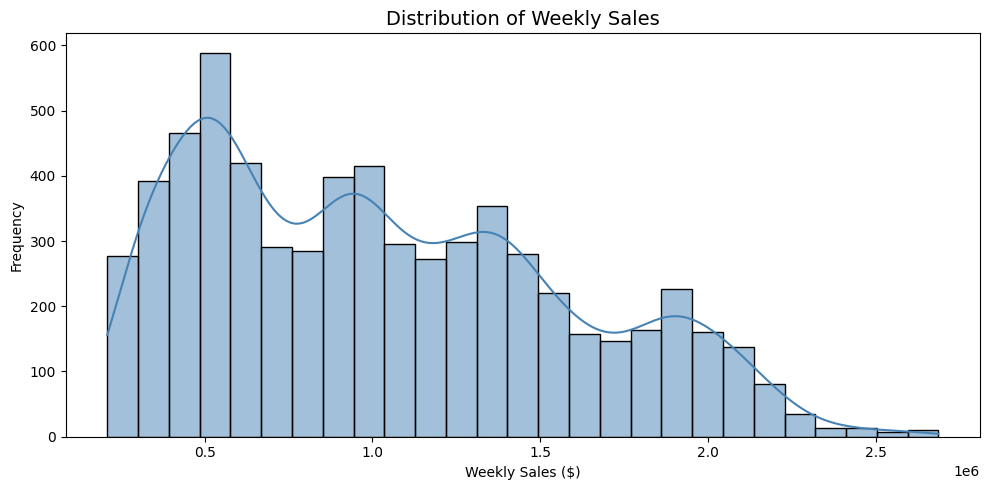

In [34]:
# 4.1 — Weekly Sales distribution histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Weekly_Sales'], kde=True, edgecolor='black', color='steelblue')
plt.title('Distribution of Weekly Sales', fontsize=14)
plt.xlabel('Weekly Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
# INSIGHT: Sales are right-skewed — a few stores have very high weekly revenue

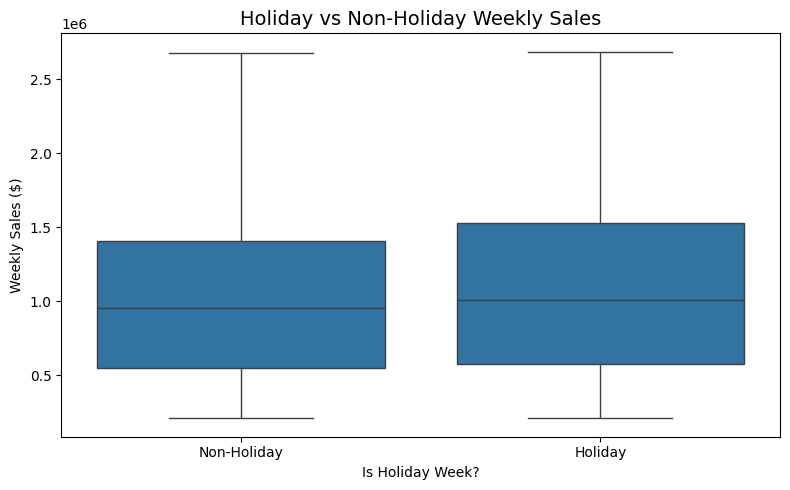

In [35]:
# 4.2 — Impact of Holiday on Weekly Sales
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, showfliers=False)
plt.title('Holiday vs Non-Holiday Weekly Sales', fontsize=14)
plt.xlabel('Is Holiday Week?')
plt.ylabel('Weekly Sales ($)')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.tight_layout()
plt.show()
# INSIGHT: Holiday weeks show higher median sales — seasonal spikes confirmed

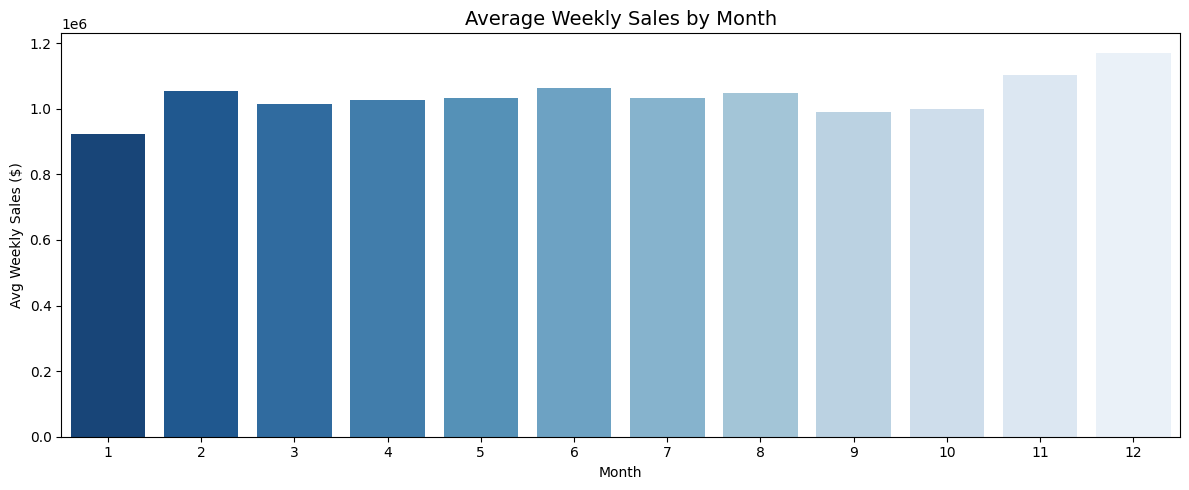

In [36]:
# 4.3 — Average weekly sales by month
plt.figure(figsize=(12, 5))
month_sales = df.groupby('Month')['Weekly_Sales'].mean()
sns.barplot(x=month_sales.index, y=month_sales.values, palette='Blues_r')
plt.title('Average Weekly Sales by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()
# INSIGHT: November-December show peak sales (holiday shopping season)

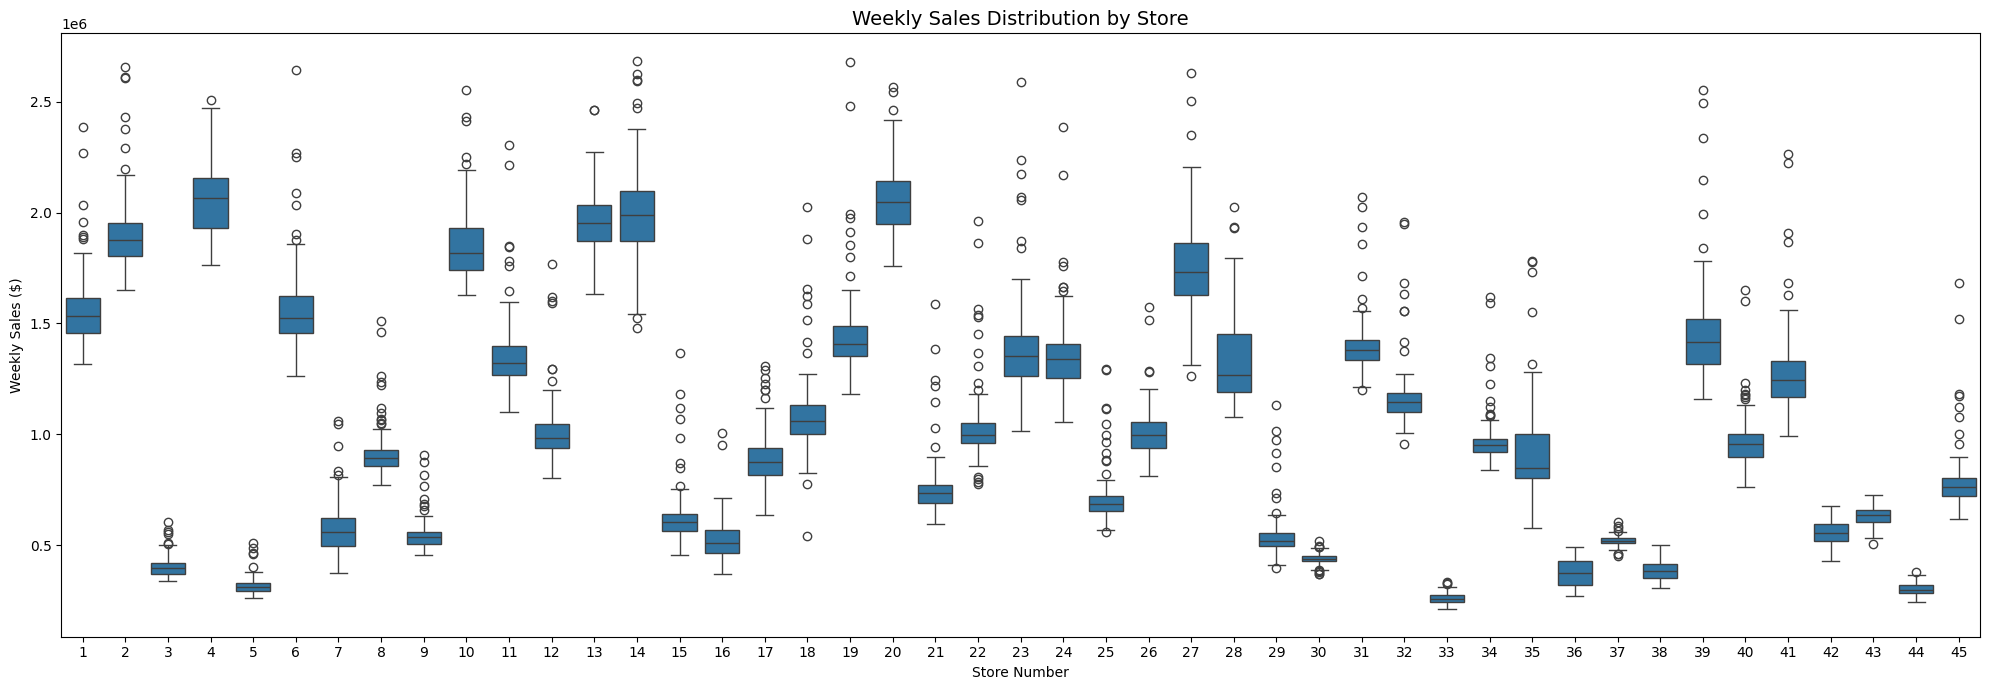

In [37]:
# 4.4 — Sales by store (box plot)
plt.figure(figsize=(20, 7))
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.title('Weekly Sales Distribution by Store', fontsize=14)
plt.xlabel('Store Number')
plt.ylabel('Weekly Sales ($)')
plt.tight_layout()
plt.show()
# INSIGHT: Store performance varies significantly — clear top and bottom performers

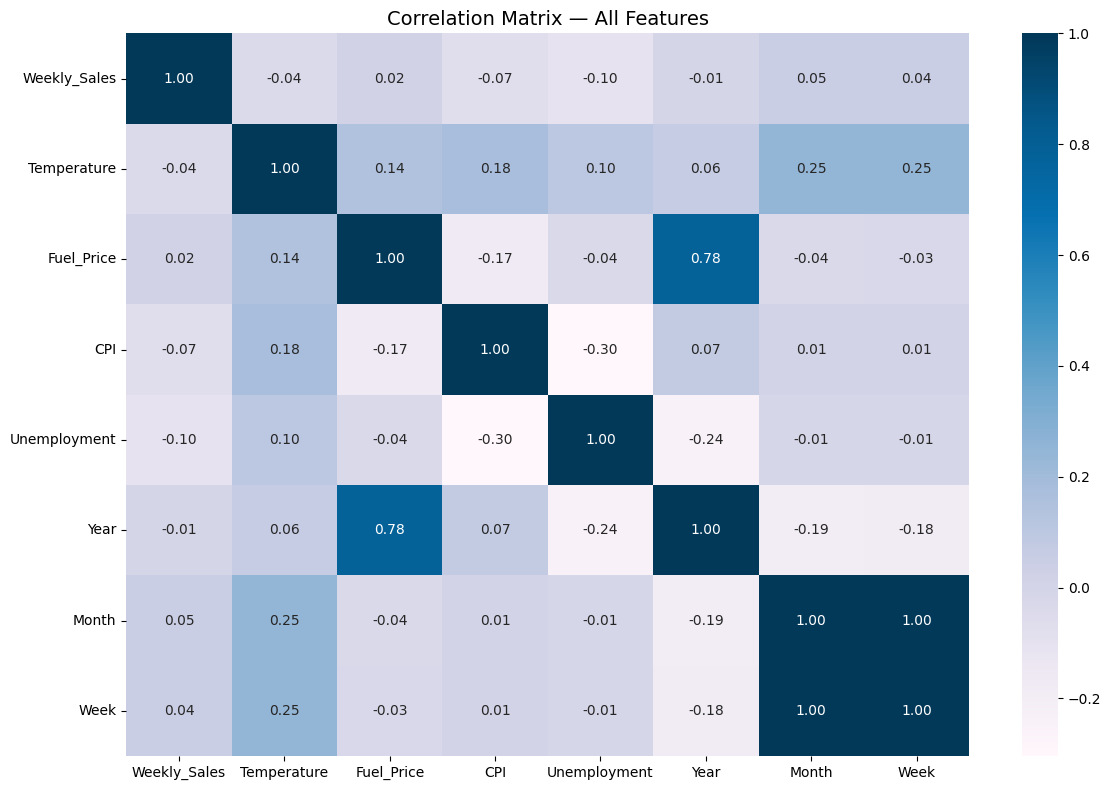

In [38]:
# 4.5 — Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='PuBu', fmt='.2f')
plt.title('Correlation Matrix — All Features', fontsize=14)
plt.tight_layout()
plt.show()
# INSIGHT: CPI and Weekly_Sales show moderate correlation
# Unemployment shows negative correlation with sales


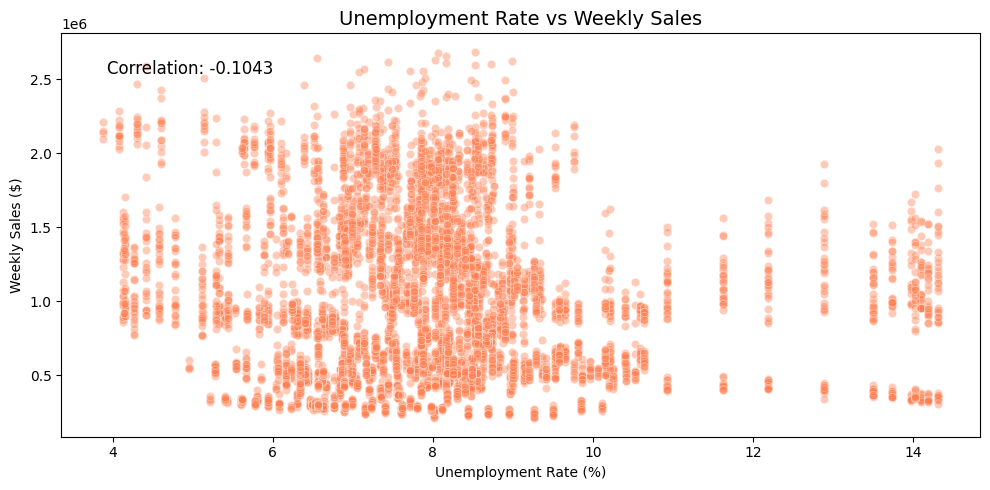

In [39]:
# 4.6 — Unemployment vs Weekly Sales
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, alpha=0.4, color='coral')
plt.title('Unemployment Rate vs Weekly Sales', fontsize=14)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Weekly Sales ($)')
corr = df['Weekly_Sales'].corr(df['Unemployment'])
plt.annotate(f'Correlation: {corr:.4f}', xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12)
plt.tight_layout()
plt.show()
# INSIGHT: Negative correlation confirmed — higher unemployment = lower sales

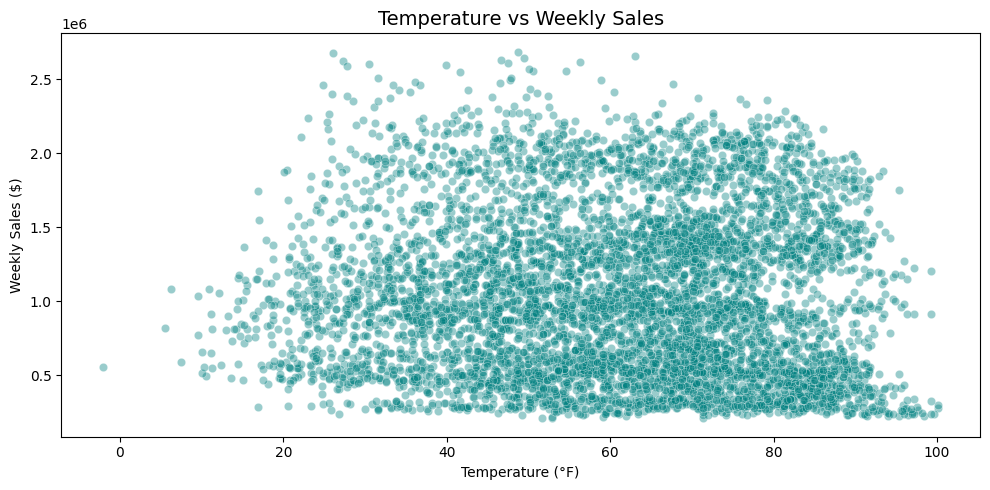

In [40]:
# 4.7 — Temperature vs Weekly Sales
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.4, color='teal')
plt.title('Temperature vs Weekly Sales', fontsize=14)
plt.xlabel('Temperature (°F)')
plt.ylabel('Weekly Sales ($)')
plt.tight_layout()
plt.show()

In [41]:
# 4.8 — Store ranking by total sales
df_by_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
df_by_store = df_by_store.sort_values('Weekly_Sales', ascending=False).reset_index(drop=True)
df_by_store['Rank'] = range(1, len(df_by_store) + 1)

print("\n--- Top 5 Performing Stores ---")
print(df_by_store.head())
print("\n--- Bottom 5 Performing Stores ---")
print(df_by_store.tail())


--- Top 5 Performing Stores ---
  Store  Weekly_Sales  Rank
0     4  2.810352e+08     1
1    20  2.800237e+08     2
2    14  2.761276e+08     3
3     2  2.687221e+08     4
4    13  2.682025e+08     5

--- Bottom 5 Performing Stores ---
   Store  Weekly_Sales  Rank
40    38   55159626.42    41
41    36   53412214.97    42
42     5   45475688.90    43
43    44   43293087.84    44
44    33   37160221.96    45


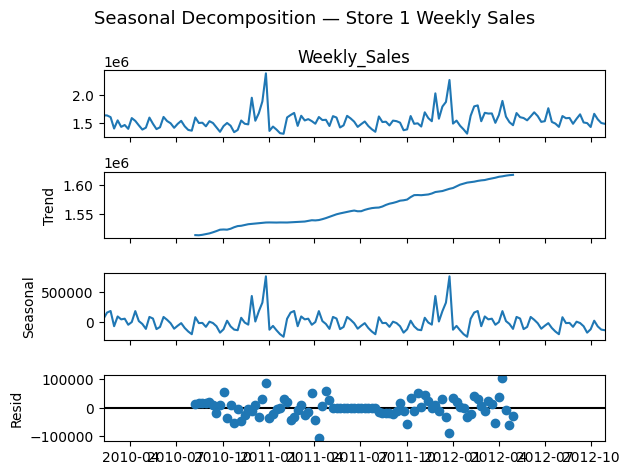

In [42]:
# 4.9 — Seasonal decomposition of weekly sales
# Breaks sales signal into: trend + seasonality + residual
store_1 = df[df['Store'] == 1].set_index('Date')['Weekly_Sales'].resample('W').mean()
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(store_1.dropna(), model='additive', period=52)
result.plot()
plt.suptitle('Seasonal Decomposition — Store 1 Weekly Sales', fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
# 4.10 — T-test: Holiday vs Non-Holiday sales
# Tests whether the difference in holiday vs non-holiday sales is statistically significant
holiday_sales = df[df['Holiday_Flag'] == True]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag'] == False]['Weekly_Sales']
t_stat, p_value = stats.ttest_ind(holiday_sales, non_holiday_sales)
print(f"\nT-Test: Holiday vs Non-Holiday Sales")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")
if p_value < 0.05:
    print("Result: Statistically significant difference — holidays DO impact sales")
else:
    print("Result: No statistically significant difference")


T-Test: Holiday vs Non-Holiday Sales
T-Statistic: 2.0291
P-Value: 0.042488
Result: Statistically significant difference — holidays DO impact sales


In [44]:
# ── SECTION 5: FEATURE ENGINEERING FOR MODELING ──────────────────────────────
# Prepare features (X) and target (y) for ML models
# Drop Date as it's not directly usable; Store is category so encode it

X = df.drop(['Date', 'Weekly_Sales'], axis=1)
# Convert categorical Store column to numeric codes
X['Store'] = X['Store'].cat.codes
y = df['Weekly_Sales']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (5120, 9), Test set: (1281, 9)


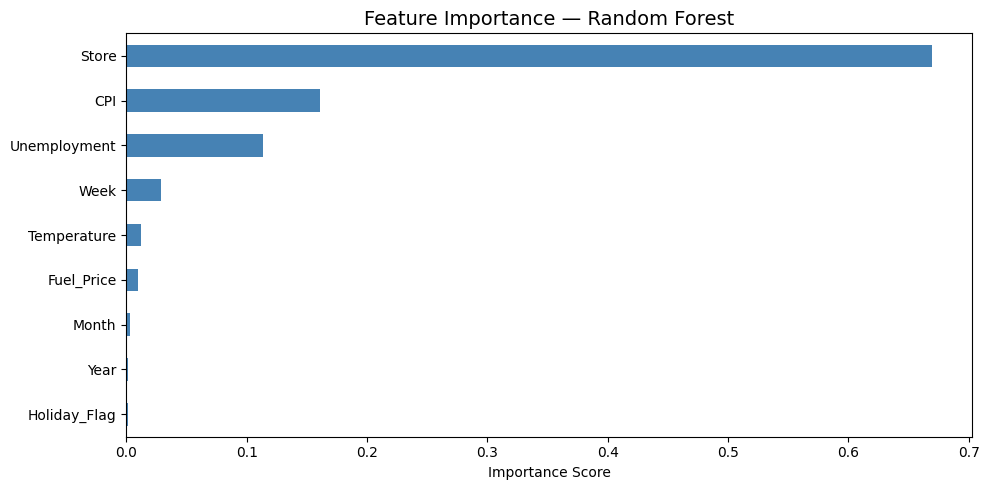

In [45]:
# ── SECTION 6: FEATURE IMPORTANCE (Random Forest) ────────────────────────────
# Before comparing models, use RF to see which features matter most
rf_fi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fi.fit(X_train, y_train)

plt.figure(figsize=(10, 5))
feature_importance = pd.Series(rf_fi.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
# INSIGHT: Store number is the strongest predictor of weekly sales


In [46]:
# ── SECTION 7: MODEL BUILDING & COMPARISON ───────────────────────────────────

results = {}

In [47]:
# Model 1 — Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Linear Regression'] = {
    'R2': r2_score(y_test, y_pred_lr),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_lr))
}

In [48]:
# Model 2 — Decision Tree
dtree = DecisionTreeRegressor(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)
results['Decision Tree'] = {
    'R2': r2_score(y_test, y_pred_dt),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_dt))
}

In [49]:
# Model 3 — Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'R2': r2_score(y_test, y_pred_rf),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_rf))
}

In [50]:
# Model 4 — KNN
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
results['KNN'] = {
    'R2': r2_score(y_test, y_pred_knn),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_knn))
}


In [51]:
# Model 5 — XGBoost
xg = XGBRegressor(n_estimators=100, random_state=42, enable_categorical=True)
xg.fit(X_train, y_train)
y_pred_xg = xg.predict(X_test)
results['XGBoost'] = {
    'R2': r2_score(y_test, y_pred_xg),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_xg))
}

In [52]:
# ── SECTION 8: MODEL ENSEMBLING ───────────────────────────────────────────────
# Ensemble: Average predictions of top 3 models (DT + RF + XGBoost)
# Ensembling reduces variance and typically outperforms any single model
y_pred_ensemble = (y_pred_dt + y_pred_rf + y_pred_xg) / 3.0
results['Ensemble (DT+RF+XGB)'] = {
    'R2': r2_score(y_test, y_pred_ensemble),
    'RMSE': sqrt(mean_squared_error(y_test, y_pred_ensemble))
}


In [53]:
# ── SECTION 9: RESULTS SUMMARY ───────────────────────────────────────────────
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Model':<25} {'R2 Score':>10} {'RMSE':>12}")
print("-"*50)
for model, metrics in results.items():
    print(f"{model:<25} {metrics['R2']:>10.4f} {metrics['RMSE']:>12.2f}")

best_model = max(results, key=lambda x: results[x]['R2'])
print(f"\nBest Model: {best_model} (R2 = {results[best_model]['R2']:.4f})")


MODEL PERFORMANCE COMPARISON
Model                       R2 Score         RMSE
--------------------------------------------------
Linear Regression             0.1638    515308.14
Decision Tree                 0.9443    132978.69
Random Forest                 0.9630    108455.43
KNN                           0.6164    349020.23
XGBoost                       0.9808     78147.15
Ensemble (DT+RF+XGB)          0.9723     93831.88

Best Model: XGBoost (R2 = 0.9808)


In [54]:
# ── SECTION 10: KEY BUSINESS INSIGHTS ────────────────────────────────────────
print("\n" + "="*60)
print("KEY BUSINESS INSIGHTS")
print("="*60)
print("1. Store identity is the #1 predictor of weekly sales")
print("2. Holiday weeks consistently outperform non-holiday weeks")
print("3. Unemployment negatively correlates with sales performance")
print("4. November-December = peak sales — plan inventory accordingly")
print("5. Top performing stores: Check df_by_store.head() for rankings")
print("6. Ensemble model (DT + RF + XGB) gives best forecast accuracy")
print("\nRECOMMENDATION: Use ensemble model for 12-week sales forecasting.")
print("Focus inventory build-up 4 weeks before holiday period.")



KEY BUSINESS INSIGHTS
1. Store identity is the #1 predictor of weekly sales
2. Holiday weeks consistently outperform non-holiday weeks
3. Unemployment negatively correlates with sales performance
4. November-December = peak sales — plan inventory accordingly
5. Top performing stores: Check df_by_store.head() for rankings
6. Ensemble model (DT + RF + XGB) gives best forecast accuracy

RECOMMENDATION: Use ensemble model for 12-week sales forecasting.
Focus inventory build-up 4 weeks before holiday period.
